# 7.1 Introduction to DPointNet

The following chapter will provide an introduction to DPointNet, a BMTK simulation engine for training and simulation (inference) of biorealistic neural networks using deep-learning techniques. This chapter uses a small toy network to demonstrate basic DPointNet usage and a number of its core features. 

In [1]:
import tensorflow as tf
import numpy as np

from bmtk.builder import NetworkBuilder

2026-07-11 11:10:03.967234: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-11 11:10:03.974824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-11 11:10:03.984917: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-11 11:10:03.984931: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-11 11:10:03.991859: I tensorflow/core/platform/cpu_feature_gua

## Building the network

<div style="display: flex; align-items: flex-start; gap: 20px;">

  <div style="flex: 1;">
    <p>First thing we must do is find or import a brain-network that we can train and run inferences on. While DPointNet can support a number of formats, the primary supported and recommend is using <a href="https://github.com/AllenInstitute/sonata/blob/master/docs/SONATA_DEVELOPER_GUIDE.md#representing-circuits">SONATA circuit format</a>. You may download existings SONATA circuit files or, using `BMTK Network Builder`, create a new network yourself - which is what we will do here. Details and tutorials on building networks with BMTK are covered in greater depth in [previous chapters](LINK) and [documentation](https://alleninstitute.github.io/bmtk/builder.html). For this chapter we just need a small toy network to demonstrate DPointNet features.
</p>
      <br>
    <p>Our core network will consist of a 300 GLIF point neurons; 200 excitatory type neurons and 100 inhibitory neurons. We will initially use an all-to-all connections with synpatic weights randomly assigned. To drive the network we will use randomized feed-forward virtual cells firing at a constant rate.
    </p>
  </div>

  <div style="flex: 1;">
    <img src="images/dpointnet_tutorial_glif_network.png" style="width: 40%;">
  </div>
</div>



Initially, without a lot of hand-tuned optimization, such a network would be expected to provide any useful results. But by training on DPointNet with built-in and customized loss functions, we can hopefully train the network to start producing interesting patterns.

### Importing cell and synaptic models

First step is to get the individual cell and synpatic parameters that will make up the individual constituent components of the networks, which in the SONATA format are typically stored in individual JSON/NeuroML files. For building a network from scratch we will need to find new cell and synpase parameters. 

One option is to download the [cell-types database to search among thousand of possible candidates](https://celltypes.brain-map.org/data). For DPointNet it's important that the cell has GLIF-3 model-params can be downloaded and placed into the appropiate folder.

<div style="display: flex; gap: 10px;">
    <img src="../../images/ctdb_screenshot.filter_cells.highlighted.png" width="350">
    <img src="../../images/ctdb_screenshot.select_model.highlighted.png" width="350">
    <img src="../../images/ctdb_screenshot.ephys_page.highlighted.png" width="350">

</div>


However we've already gone ahead and selected cell-type models, one excitatory and one inhibitory cortical cell, that are being used in the [V1 Model paper](LINK). They have been placed in the **components/** directory. You can also download all the V1 Models into your simulation environment by running the following command:

In [2]:
# ! python -m bmtk.utils.dpointnet import-models --model V1 --output components/

/home/kael/apps/miniconda3/envs/workshop2026-py3.11-gpu/bin/python: No module named bmtk.utils.dpointnet


### Building the network

Using the JSON parameter files stored in the **components/** directory, we can build our core network. We will call it "glifs" and save it to the **network/** folder. 

Note that the `syn_weight` are being assigned at random with a large range of values, since at the moment we don't have any idea what values they should take on (which will be dependent on how we eventually train the network). The only thing we must take care-of is to keep inhibitory connections negative and exciatory connection postive.

In [3]:
n_exc = 200
n_inh = 100

rnet = NetworkBuilder('glifs')
rnet.add_nodes(
    N=n_exc,
    ei='e',
    pop_name='e4Nr5a1',
    model_type='point_neuron',
    model_template='glif_psc_double_alpha',
    dynamics_params='354833767_glif_lif_asc_config.json'
)

rnet.add_nodes(
    N=n_inh,
    ei='i',
    pop_name='i4Vip',
    model_type='point_neuron',
    model_template='glif_psc_double_alpha',
    dynamics_params='501570114_glif_lif_asc_config.json'
)

cm = rnet.add_edges(
    source={'ei': 'e'}, target={'ei': 'e'},
    connection_rule=lambda s, t: 0 if s.node_id == t.node_id else 1,  # Note, we must take care here not to connect autoapses
    dynamics_params='glif_e2e.json',
    model_template='static_synapse',
    delay=2.0
)
cm.add_properties(
    names='syn_weight',
    rule=lambda *_: np.random.uniform(1.0, 30.0)
)

cm = rnet.add_edges(
    source={'ei': 'e'}, target={'ei': 'i'},
    connection_rule=1,
    dynamics_params='glif_e2i.json',
    model_template='static_synapse',
    delay=2.0
)
cm.add_properties(
    names='syn_weight',
    rule=lambda *_: np.random.uniform(1.0, 30.0)
)

cm = rnet.add_edges(
    source={'ei': 'i'}, target={'ei': 'e'},
    connection_rule=1,
    dynamics_params='glif_i2e.json',
    model_template='static_synapse',
    delay=2.0
)
cm.add_properties(
    names='syn_weight',
    rule=lambda *_: np.random.uniform(-1.0, -30.0)
)

cm = rnet.add_edges(
    source={'ei': 'i'}, target={'ei': 'i'},
    connection_rule=lambda s, t: 0 if s.node_id == t.node_id else 1,
    dynamics_params='glif_i2i.json',
    model_template='static_synapse',
    delay=2.0
)
cm.add_properties(
    names='syn_weight',
    rule=lambda *_: np.random.uniform(-1.0, -30.0)
)

rnet.build()
rnet.save('network')


Similary we want to create a separate network of feed-forward cells to stimulate out network using `virtual` cells. `virtual` cells are not bio-realistic models but just place-holders for pre-synaptic spike trains, which we will generate later during training and inference. 

Like in with recurrent synaptic weights, the `syn_weight` property is choosen at random. And like with recurrent synapse, we can train them with specific inputs and loss functions.

In [4]:
vnet = NetworkBuilder('virts')
vnet.add_nodes(
    N=100,
    ei='e',
    model_type='virtual'
)

cm = vnet.add_edges(
    target=rnet.nodes(ei='e'),
    connection_rule=1,
    dynamics_params='virt_e2e.json',
    model_template='static_synapse',
    delay=2.0
)
cm.add_properties(
    names='syn_weight',
    rule=lambda *_: np.random.uniform(1.0, 30.0)
)

cm = vnet.add_edges(
    target=rnet.nodes(ei='i'),
    connection_rule=1,
    dynamics_params='virt_e2i.json',
    model_template='static_synapse',
    delay=2.0
)
cm.add_properties(
    names='syn_weight',
    rule=lambda *_: np.random.uniform(1.0, 30.0)
)

vnet.build()
vnet.save('network')

After running the code above we should have a SONATA network of 300 recurrently connected GLIF neurons using two different cell-types. They recieve inputs from 100 feed-forward `virtual` cells. As represented with the following structure in our current directory.


<div style="width=300 align="left" style="margin-left:26px">
    <img src="images/bmtk_workshop_dpointnet_network_setup.png" width="500">
</div>

## Training and Inference

Now that we have a SONATA network that we have either downloaded or generated using the code above, we want to use DPointNet simulation engine to do one or both of the following:

* **Train** the network on know input with expected results.
* **Run Inference (ie. Simulation)** on the network to see how the model responds to novel stimuli.

With BMTK, we do easily do both using the same code. And like with other simulation engines, the prefered method for running either can be done using [SONATA JSON configuration file](LINK) (Example of how to use DPointNet with just the Python API can be found [HERE](LINK). 


### Running initial inference

While the above network we created has not had its weights tunned in training, and thus not expected to produce anything informative, it is still a valid simulatable network. And it will be helpful to see how, even when untrained, our untrained network responds to various stimuli.

To run a simulation on this, or any, full network we will first create a SONATA configuration file that contains everything need to run a simulation on the network. You can take an existing **DPointNet** json config, or generate an outline template with the following command:

In [5]:
# ! python -m bmtk.utils.dpointnet import-config --model V1 --use-defaults --add-section --output config.inference.template.json

Then make the appropiate edits of the JSON file using your prefered text editor.

We've already created a config file called *config.inference.json* which all the major sections filled. But in general the DPointNet configuration fill will have the following sections

<div style="width=300 align="left" style="margin-left:26px">
    <img src="images/dpointnet_config_overview.png">
</div>

Now we will go over the major sections of the SONATA config.

#### **DPointNet SONATA config sections**: `"network"` and `"components"`

First we must BMTK where to find the SONATA network files, along with any associated cell and synpatic parameters file, that we built and downloaded above. We do so in the "networks" and "components" section of the JSON config, respectively, as here:


```json
    "components": {
        "point_neuron_models_dir": "$MODELS_DIR/cell_models",
        "synaptic_models_dir": "$MODELS_DIR/synaptic_models"      
    },
    
    "networks": {
        "nodes": [
          {
            "nodes_file": "$NETWORK_DIR/glifs_nodes.h5",
            "node_types_file": "$NETWORK_DIR/glifs_node_types.csv"
          },
          {
            "nodes_file": "$NETWORK_DIR/virts_nodes.h5",
            "node_types_file": "$NETWORK_DIR/virts_node_types.csv"
          }
        ],
        "edges": [
          {
            "edges_file": "$NETWORK_DIR/glifs_glifs_edges.h5",
            "edge_types_file": "$NETWORK_DIR/glifs_glifs_edge_types.csv"
          },
          {
            "edges_file": "$NETWORK_DIR/virts_glifs_edges.h5",
            "edge_types_file": "$NETWORK_DIR/virts_glifs_edge_types.csv"
          }
        ]
      }
```

As with other BMTK simulators, we can use these sections to dynamically change the networks at simulation time. If you want to combine multiple recurrent networks into one, add or remove feed-foward inputs; you can do so by altering the list of "nodes" and "edges". Each time you run an inference or simulation (see below) it will combine all files into a single unified network.

For other options availabe in the "networks" section, including how to use different formats, please see [HERE](LINK).


#### **DPointNet SONATA config sections**: `"run"`

The "run" section of the config is used to specify global options for both inference and training. Including how length, time-step, default random seeds, as-well-as options for GPU usage and data-types

```json
    "run": {
        "seq_len": 500,
        "dt": 1.0,
        "t_start": 0.0,
        "default_seed": 3000,
        "batch_size": 10,
        "train_recurrent_weights": true,
        "dtype": "float32",
        "single_gpu_strategy": "one_device"
    }
```

The important part is that we want to tell BMTK that during inference (and training) we want to use 500 ms inputs using a dt of 1 ms, which you may want to change depending on the network and stimuli used. If DPointNet is running out of memory, or you need greater precision, you can also change `dtype` to a like `float16`, `float8` or `float32` (this will affect some of the underlying data-types, but not all).

Also if you only want to train feed-forward weights you can set `train_recurrent_weights` to `false`.

For more explaination of options in "run" section see [HERE](LINK).


#### **DPointNet SONATA config sections**: `"rnn_cell_param"`

The "rnn_cell_params" are model specific cell hyperparameters used by the underlying Recurrent Neural Network (RNN) implmentation. This includes information about how certain parts of the RNN are simulated and how gradients are calculated in training.

```json
    "rnn_cell_params": {
        "cell_model": "GLIF3Cell",
        "gauss_std": 0.5,
        "dampening_factor": 0.3,
        "recurrent_dampening_factor": 0.5,
        "voltage_gradient_dampening": 0.5,
        "recurrent_weight_scale": 1.0,
        "pseudo_gauss": false,
        "lr_scale": 1.0,
        "max_delay": 5,
        "hard_reset": false,
        "tau_basis": [0.7579732, 1.60809441, 3.41168742, 7.23813909]
    }
```

Our network is made up of "GLIF3Cell" type "cell_model"s - which is an implmentation of [GLIF models](LINK) using an RNN cell in tensorflow. If/when other models become available you will need to swap "cell_model" plus potentially other options.

We are using the default options that have been tested with larger, more realistic models. However depending on the nature of the model and inputs you are using, you may want to change a number of the hyperparameters. More information about available options can be found [HERE](LINK).

#### **DPointNet SONATA config sections**: `"inputs"`

The "inputs" section used to tell BMTK how to generate stimuli (in this case pre-synaptic spike trains) for the `virtual` cells.

```json
    "inputs": {
        "rand_inputs": {
            "node_set": "virts",
            "input": "spikes",
            "module": "bernoulli_spikes",
            "firing_rate": 10.0
        }
    }
```

In our case we are generating random spikes firing at 10 Hz. 
* `node_set` is used to indicate which set of nodes to apply the inputs to. **virts** is the name we called the population of `virtual` cells we created above.
* `input` indicates the modality of the inputs, in this case we are generating `spikes` trains
* `module` is the underlying code we are using to generate the spikes. Here **bernoulli_spikes** is the name of a built-in bmtk module that generates a random spike-trains at a certain `firing_rate`. There are also other built-in modules that include inputs form pregnerated files, generated from audio/visual inputs, fom custom user defined functions, or even create your own "inputs" module. The options (like firing_rate) will vary from module-to-module. See [here](LINK) for a list of built-in modules.


Note that in our case we only had one population of inputs, called **virts**, so the "inputs" only contained one subsection. If we added more inputs, say from different parts of the brain, we'd need to have more subsections:

```json
    "inputs": {
        "thalamus_inputs": {
            "node_set": "thalamus_virts",
            "input": "spikes",
            "module": "LGN_generator",
            ...
        },
        "hippocampus_inputs": {
            "node_set": "hippo_virts",
            "input": "spikes",
            "module": "from_file",
            ...
        },
        ...
    }
```

In general, each population of `virtual` cells should have at-least one "inputs" subsection. But in the case where you are running multiple inference/training session in the same simulation the same `node_set` can have multiple modules. For example you want to train with both noisy and static **virts** inputs, then validate it against pregenerated spike files. You just need to specify when each module will be applied inside the "inference" and/or "training" sections (described below).


#### **DPointNet SONATA config sections**: `"initial_states"`

Other than spike-inputs, the back-end RNN layer requires you to set an initial state of the model params before it start running any inference or training. For our simple model we can set the initial state parameters to be zeros by setting:

```json
    "initial_states": [
      {
        "name": "zero_state_input",
        "module": "zero_state"
      }
    ]

```

Other options inlcude setting the initial state parameters randomly, using the final state of one feed-forward pass as the input, from a file or directly from user function. For more about initial state features see [here](LINK).


#### **DPointNet SONATA config sections**: `"output"`

```json
    "output": {
        "output_dir": "$OUTPUT_DIR",
        "log_file": "log.txt",
        "log_level": "DEBUG",
        "spikes_file": "spikes.h5",
        "voltages_file": "voltages.h5"
    }
```


The "output" section, like with the other engines, is used to specify logging and output of files. For each inference we run there the model produces three outputs:
1. The spikes generate by each neuron
2. The voltage traces of each neuron
3. The state of the model.

Our output section is telling us to save spikes and voltage traces in SONATA format, into the **output/** directory. Similarly we will also save the logging into **output/log.txt**.


#### **DPointNet SONATA config sections**: `"inference"`

Finally we have the "inference" section

```json
    "inference": {
      "initial_state": {
          "module": "zero_state"
      },

      "inputs": [
          "rand_inputs"
      ]
    }
```

To run an inference on the network we just need to specify the which modules to use for `initial_state` and `inputs`, and where to save any results. Since we've already defined those in parent sections of the config, we just reference them by their module name (this allows us to re-use modules across multiple inferences and training sessions).


**NOTE: inference and training**

As users may have noticed, we said above that DPointNet does both "inference" and "training", but *config.inference.json* only contains an "inference" section. As you might expect this means when we use this config no training will be done. A DPointNet config may have only a "inference" section, only a "training session", or can have both (in which case DPointNet will train the network first then run inference on the updated weights). In the next part of the chapter we will expand on the current config to add training.


### Running a Inference Session

Now that we have a network, plus a SONATA JSON config with instructions on how to run an inference session (including simulation parameters, inputs, and outputs), we are ready to run initial feedforward simulaions of our model. Remember that our model as of the moment is untrained and using randomized inputs, which won't provide much useful results other than check the results of training we do later!

We can run the session in a command line, including through HPC like slurm, using the following command (if using HPC the actuall command may vary depending on system).

```bash
    $ python run_dpointnet.py config.inference.json
```

or directly through the jupyter cell

<div class="alert alert-block alert-info">
<b>ALERT</b>: When you first run the simulation in Jupyter or Python you will see a large number of red cuda and tensorflow message that are not a normal BMTK/Python messaging. This is to be expected, and is a normal part of running tensorflow.
</div>

In [6]:
from bmtk.simulator import dpointnet
dpointnet.reset() ## Note: this is only required due to use of jupyter, and generally not recommend when running using python command

config = dpointnet.Config.from_json('config.inference.json')
config.build_env()

rnn_network = dpointnet.RNN.from_config(config)
untrained_results = rnn_network.run()

2026-07-11 11:12:10,848 [WARNING] Directory ./output already exists.
2026-07-11 11:12:10,848 [INFO] Created log file
2026-07-11 11:12:10,849 [INFO] TensorFlow precision policy set to "float32" (compute_dtype=float32, variable_dtype=float32, requested_dtype=float32).
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
2026-07-11 11:12:11,019 [DEBUG] Loading network glifs from ./network/glifs_nodes.h5
2026-07-11 11:12:11,022 [DEBUG] Loading network virts from ./network/virts_nodes.h5
2026-07-11 11:12:11,025 [DEBUG] Adding edges to glifs
2026-07-11 11:12:11,027 [DEBUG] Adding edges to virts
2026-07-11 11:12:11,031 [INFO] Building "rand_inputs" inputs for virts
2026-07-11 11:12:11,031 [INFO] RNN.run() starting...
2026-07-11 11:12:11,031 [INFO] Building Model.


2026-07-11 11:12:10.851446: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 11:12:10.879178: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 11:12:10.883281: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

2026-07-11 11:12:11,204 [DEBUG]  > Added recurrent synapses: indices = 89700; trainable = True
2026-07-11 11:12:11,208 [DEBUG]  > Added "virts" input synapses: indices = 30000, trainble = False
2026-07-11 11:12:11,459 [INFO] Running Inference on Model (inference).
2026-07-11 11:12:17,908 [INFO] Saving Results to file.
2026-07-11 11:12:17,915 [INFO] RNN.run() completed.


As mentioned from the "output" section above the results, specifically the spikes and voltage traces, will have been saved to the **output/** directory when completed. We can also use the returned `results` of our `run()` to plot and get statistics of inference.

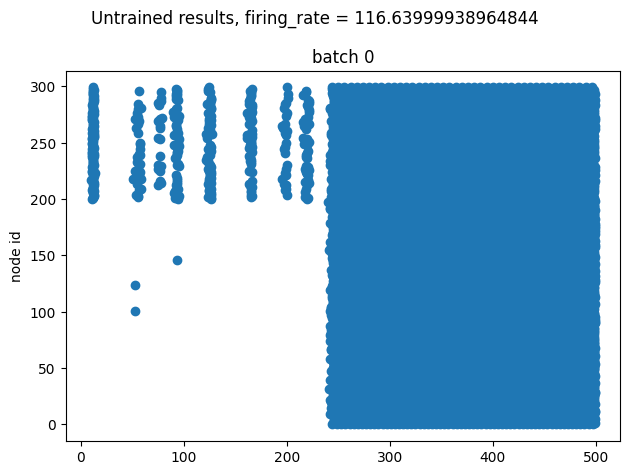

In [13]:
untrained_fr = untrained_results.spikes.mean_firing_rate()
fig = untrained_results.spikes.raster(batch_nums=0, show=False)
fig.suptitle(f'Untrained results, firing_rate = {untrained_fr}')
fig.tight_layout()

## Training

Now that we've seen the behavior of the untrained model, the rest of the tutorials will be focused on training the network to more complex patterns and inputs. Prehaps the simplest training we can do is train the network so that cells fire at specified firing rate. Simply put, we want to make it so that given the randomized input defined above, we want the network to make it so that all cells fire within a givin firing rate range.

As with inference we can set-up training through the SONATA JSON config. You can create a config template from scratch using the following command:



In [8]:
# ! python -m bmtk.utils.dpointnet import-config --model V1 --use-defaults --add-section inference --add-section training --output config.training.template.json

Or alternatively take an existing config file, like the *config.inference.json* from above; copy, rename, and update it to also allow for training. 

For the following example we will use the *config.train.uniform_fr.json* file. It utilizes all the same sections as in the inference, and includes extra "training" section. Now we will briefly describe the file in more detail:

#### **DPointNet SONATA config sections**: `"training"`

```json
  "training": {
    "n_epochs": 5,
    "steps_per_epoch": 10,
    ...
  }
```

The parameters used during training will be set in under the "training" section. We initialially set the main parameters, most importantly the maximum number of `epochs` and `steps_per_epoch`, as this will dictate how much training will be done. A list of available hyperparameters can be found [here](LINK).

#### **DPointNet SONATA config sections**: `"learning_rate"` and `"optimizer"`

In this section we define both the learning-rate and internal optimization functions used during training

```json
    "learning_rate": {
      "schedule": "warmup_cosine",
      "warmup_start_lr": 0.001,
      "warmup_target_lr": 0.04,
      "warmup_steps": 120,
      "cosine_steps": 880,
      "min_lr": 0.001
    },
    "optimizer": {
      "name": "adam",
      "epsilon": 1.0e-07
    }
```

DPointNet has a number of built-in learning rate schedudels and optimizers. Alternatively you can use one of the built-in keras optimizers or import your own. For more information see [here](LINK).

#### **DPointNet SONATA config sections**: `"initial_state"`

Like with inference section, we need to specify the initial state of the RNN parameters used at the start of each training step/epoch. Here we use the same `module` used in inference, which is to set the intial_state parameters of the RNN at each training step to be zeros. We can re-use the same above-scope definition by just referencing the name:

```
    "initial_state": {
      "module": "zero_state"
    }
```

For more advanced training, we may want different modules (eg starting states) for inference, training, and validation. In such case we just need to add the extra section and references to the config. 


#### **DPointNet SONATA config sections**: `"callbacks"`

The callbacks class is responsible for monitoring and logging the training at each step of the process. Among the things it's responsible for include:
* Logging and printing current results
* Storing and saving losses and validations at each step/epoch
* Storing and saving GPU/CPU information at each step/epoch
* Keeping track of best results
* Monitoring if training session should be prematurely stopped.
* Saving best trained weight(s) to file

All the above options can be changed in the config `"class": "Callbacks"` class built into DPointNet

```json
    "callbacks": {
      "class": "Callbacks",
      "starting_epoch": 0,
      "verbose": "on_step",
      "callbacks_dir": "training_uniform_fr",
      "epoch_store_weights": "best",
      "sonata_output_dir": "network_uniformed_weights",
      "losses_table_csv": "losses.csv",
      "performance_table_csv": "performance.csv"
    }
```

We set the `starting_epoch` to 0 (the default) which just indicates we want to start from scratch and ignore any other potential previous training. For example if we had a previous training session that didn't full complete we may want to load in previous training results and start from a different epoch.

The `verbose`, along with logging options, allows us to control what will get logged at to where.

The `callbacks_dir` indicates we want to store all the training information in the **network_uniformed_weights/** directory. These include tables which recorded the training `losses` and GPU/CPU `preformance`. The also includes how and where we want to save the updated network weights after each epoch. For this example only the `best` weights (eg. based on validation) will be saved in SONATA network format under the **network_uniformed_weights** folder.

User can also create and attach their own Callbacks class.

#### **DPointNet SONATA config sections**: `"parameters"`

The parameters contain the core of the training session, specifically the "inputs" used at each training step and the loss function(s) used to update gradients based on expected results.

The **inputs** are just like that in the inference section, and to save memory and run-time we will be reusing the exact the "module" (which just generated randomized spike trains at a given firing rate). Since the module and parameters are defined in the outer scope we just need to reference it by the name:

```json
    "inputs": [
      "rand_inputs"
    ]
```

Since we only have one input population of virtual cells, eg `virts`, we only use the one module. If we had multiple input populations to our recurrent network then the "inputs" section would be a list of "input" modules.


Finally we have the **loss_functions**, the most import part of training, that takes the inputs, the outputs of each training step (eg recurrent spike-trains and voltage traces), and calculates the loss value that will be used for updating the weights. DPointNet contains a number of built-in loss functions that are specifically useful to training biorealistic brain models, or you create your own. But in our simple example we only need two built-in loss functions.

To initalize them for use during training we need to specify the `"module"` then followed by the specific parameters. 

```json
    "loss_functions": {
      "firing_rate_regularizer": {
        "module": "TargetFiringRate",
        "firing_rate": 20.0
      },
      "voltage_regularizer": {
        "module": "VoltageRegularization",
        "voltage_cost": 1.5,
        "penalty_mode": "range"
      }
    }
```

The `TargetFiringRate` module is a loss function used to train either population or individual cells to fire at a given target rate (in Hz). By setting the `firing_rate` option to a scale value, DPointNet training will work towards making all cells fire at the target rate. We can also use the same module to have groups of cells fire at a target rate (ex. inhibitory cells all fire at 5Hz, excitatory cells at 20Hz), or even set distinct firing rate targets for individual cells.

The `VoltageRegularization` module is used to regulate the voltage to make sure voltage traces of cells stay within a realistic range. It is a good loss function to use in most training situations.



### Running Training (and Inference) Session

Now that we have told DPointNet how to train our network, we can use the exact same method as above to run training session. Since our config has both a "training" and "inference" session, the default behavior of DPointNet is to train the network weights first, then run an inference session so that we can check the results and compare it to the untrained network.

Either through the command line run:

```bash
    $ python run_dpointent.py config.train.uniform_fr.json
```

or use the cell below

In [9]:
from bmtk.simulator import dpointnet
dpointnet.reset() ## Note: this is only required due to use of jupyter, and generally not recommend when running using python command

config = dpointnet.Config.from_json('config.train.uniform_fr.json')
config.build_env()

rnn_network = dpointnet.RNN.from_config(config)
trained_results = rnn_network.run()

2026-07-11 11:13:34,617 [WARNING] Directory ./output already exists.
2026-07-11 11:13:34,618 [INFO] Created log file
2026-07-11 11:13:34,619 [INFO] TensorFlow precision policy set to "float32" (compute_dtype=float32, variable_dtype=float32, requested_dtype=float32).
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
2026-07-11 11:13:34,623 [DEBUG] Loading network glifs from ./network/glifs_nodes.h5
2026-07-11 11:13:34,626 [DEBUG] Loading network virts from ./network/virts_nodes.h5
2026-07-11 11:13:34,628 [DEBUG] Adding edges to glifs
2026-07-11 11:13:34,630 [DEBUG] Adding edges to virts
2026-07-11 11:13:34,633 [INFO] Building "rand_inputs" inputs for virts
2026-07-11 11:13:34,662 [INFO] RNN.run() starting...
2026-07-11 11:13:34,662 [INFO] Building Model.
2026-07-11 11:13:34,691 [DEBUG]  > Added recurrent synapses: indices = 89700; trainable = True
2026-07-11 11:13:34,694 [DEBUG]  > Added "virts" input synapses: indices = 30000, trainbl

I0000 00:00:1783793616.126813 1661976 service.cc:145] XLA service 0x7bf780026160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783793616.126836 1661976 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-07-11 11:13:36.129205: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-11 11:13:36.137791: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1783793616.179230 1661976 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2026-07-11 11:13:36,678 [INFO] >>> Epoch  1/ 5, Step  1/10 (run time: 1.95 s, Rate: 0.2085)
2026-07-11 11:13:36,679 [INFO] >>>   Loss: 35301.1289 (default: 34992.8008, 308.3300)
2026-07-11 11:13:36,701 [INFO] >>>   "GPU:0" Memory Used:   4.52 GiB, Free  19.03 GiB, Total  24.00 GiB.
2026-07-11 11:13:37,715 [INFO] >>> Epoch  1/ 5, Step  2/10 (run time: 0.98 s, Rate: 0.2077)
2026-07-11 11:13:37,716 [INFO] >>>   Loss: 34989.6758 (default: 34688.3320, 301.3435)
2026-07-11 11:13:37,741 [INFO] >>>   "GPU:0" Memory Used:   4.51 GiB, Free  19.04 GiB, Total  24.00 GiB.
2026-07-11 11:13:38,699 [INFO] >>> Epoch  1/ 5, Step  3/10 (run time: 0.94 s, Rate: 0.2082)
2026-07-11 11:13:38,699 [INFO] >>>   Loss: 35176.8438 (default: 34881.7930, 295.0518)
2026-07-11 11:13:38,729 [INFO] >>>   "GPU:0" Memory Used:   4.51 GiB, Free  19.04 GiB, Total  24.00 GiB.
2026-07-11 11:13:39,727 [INFO] >>> Epoch  1/ 5, Step  4/10 (run time: 0.97 s, Rate: 0.2077)
2026-07-11 11:13:39,727 [INFO] >>>   Loss: 34951.2930 (defa

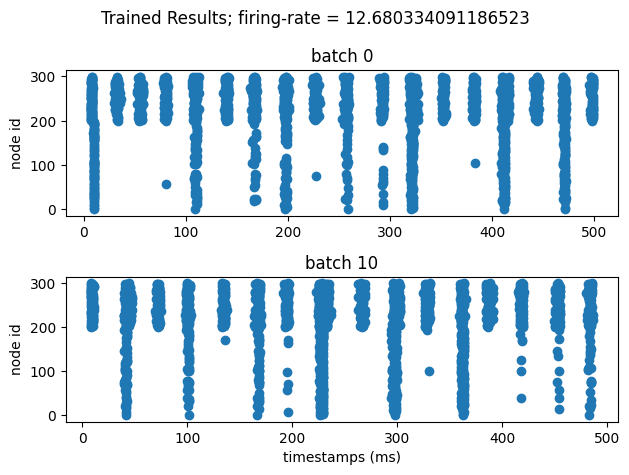

In [11]:
trained_fr = trained_results.spikes.mean_firing_rate()
fig1 = trained_results.spikes.raster(batch_nums=[0, 10], show=False)
fig1.suptitle(f'Trained Results; firing-rate = {trained_fr}')
fig1.tight_layout()

Hopefully if training has went well we should see new results with much more reasonable and expected results. 

When it has completed we should also see a a new directory **training_uniform_fr/**. Inside it should contain the directory **network_uniformated_weights/** which contains a single hdf5 weights file. Since we choose the option `"epoch_store_weights": "best"` we should have only one updated weights file for each network and know that it had the best results during validation (Other options may save multiple weight files, or may save weights file (`all`) that don't neccessarily have the best validation results (`latest`).

However, because we have very little structure and only the most primative loss function we may still need to additional hyperparamter optimization and training. And even then there is only so much we can do with such a small and simple network. Training a network to reproduce biological relevant behavior depends heavily on the nature of the brain circuit, the modality of the stimuli, and the training regimen. 

In the next section we will show a more concrete example of training a reduced model of the Mouse Visual Cortex with a variety of different visual stimuli.

[**Proceed to Chapter 7.2**](../Ch7.2_v1_examples/dpointnet_workshop_tutorial.ipynb)




## Advance Options: Custom Inputs and Losses